In [ ]:
import numpy as np, matplotlib.pyplot as plt, scipy as sp
import torch
import time

hbar = sp.constants.hbar
pi = sp.constants.pi

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found. Check your runtime settings.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define simulation parameters

class GPE:

    def __init__(self, Np, m, omega, a0, a02, gamma, sigma, N, ev_time, time_steps, cutoff_coeff, cutoff, waist=False, imag_waist=False, high_precision=False):

        self.debug = False

        if high_precision:
            self.complex_type = torch.complex128
            self.real_type = torch.float64

        else:
            self.complex_type = torch.complex64
            self.real_type = torch.float32


        self.Np = Np
        self.m = m  #kg
        self.omega = omega #Hz
        self.a0 = a0 #m
        self.g0 = 4*pi*hbar**2*a0* Np/m
        self.gamma = gamma
        self.a02 = a02
        self.g2 = 6*np.sqrt(5) * pi * hbar**2 * a02 * Np / m
        self.sigma = sigma



        self.l = np.sqrt(hbar/(m * omega)) #length scale
        self.tau = 1/omega # time scale
        self.G0 = self.g0/(self.l**3*hbar*omega)
        self.G2 = self.g2/(hbar*omega*self.l**5)

        self.waist = waist
        self.imag_waist = imag_waist
        self.cutoff = cutoff

        self.up = 3 * sigma


        self.N = N
        self.ev_time = ev_time #s
        self.time_steps = time_steps
        self.dt = ev_time/time_steps
        self.dtau = self.dt/self.tau
        self.times = np.linspace(0, ev_time, time_steps)

        self.x = torch.linspace(-self.up,self.up,self.N+1, device=device, dtype=self.real_type)[:-1]
        self.dx = (self.x[1]-self.x[0]).item(); self.dxu = self.dx/self.l

        self.X, self.Y, self.Z = torch.meshgrid(self.x,self.x,self.x, indexing='ij')
        self.uX,self.uY, self.uZ = self.X/self.l, self.Y/self.l, self.Z/self.l

        k = 2*pi*torch.fft.fftfreq(self.N, d=self.dx/self.l, device=device, dtype=self.real_type)
        self.KX, self.KY, self.KZ = torch.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z
        self.cutoff_coeff = cutoff_coeff
        self.k_cutoff = pi/self.dx * (self.cutoff_coeff) #m^-1

        if a02 == 0:
            self.elastic_term = False

        else: self.elastic_term = True


        self.init_wf = self.gaussian().to(device)
        self.n0 = torch.max(torch.abs(self.init_wf)**2).item() * self.Np
        self.healing_length = 1/np.sqrt(8*pi*self.n0*a0)

    def params(self):
        print("-- Simulation Parameters --")
        print("Number of particles:", self.Np)
        print("Mass (kg):", self.m)
        print("Trap frequency (Hz):", self.omega)
        print("Gamma: ", self.gamma)
        print("Scattering length a0 (m):", self.a0)
        print("Scattering length a02 (m^3):", self.a02)
        print("g2/g0:", self.g2/self.g0)
        print("Evolution time (s):", self.ev_time)
        print("Time steps: ", self.time_steps)
        print("dt: ", self.dt)
        print("dtau = dt/tau: ", self.dtau)
        print("Unitless Time (time/tau): ", self.ev_time/self.tau)
        print("Number of 1D grid points: ", self.N)
        print("dx:", self.dx)
        print("Healing length (m):", self.healing_length)
        print("dx/healing length:", self.dx/self.healing_length)
        print("up/healing length: ", self.up / self.healing_length)
        print("cutoff coeff:", self.cutoff_coeff)
        print("Cutoff Type: ", self.cutoff)
        print("K_Max: ", self.KX.max().item())
        print("Peak Density: ", self.n0)
        print("na0^3: ", self.n0 * self.a0**3)




    def gaussian(self):
        sigma, dx = self.sigma, self.dx
        x, y, z = self.X, self.Y, self.Z
        gaussian = torch.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).to(self.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
        norm = torch.sum(torch.abs(gaussian)**2) * dx**3
        gaussian *= (1/norm)**(1/2)
        return gaussian

    def soft_cutoff(self):

        kc = self.k_cutoff * self.l
        delta_k = 0.1 * kc  # Unitless smearing width

        kx, ky, kz = self.KX, self.KY, self.KZ

        K_mag = torch.sqrt(kx**2+ky**2+kz**2)

        #exponent = torch.clip((K_mag - kc)/delta_k, -700, 700)

        #sig = 1/(1+torch.exp(exponent))

        sig = torch.sigmoid(-(K_mag - kc)/delta_k)

        return sig

    # Define operators

    def trap_potential(self):
        gam = self.gamma
        x,y,z = self.uX, self.uY, self.uZ
        return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

    def g0_term(self, psi): # in position basis
        return self.G0 * torch.abs(psi)**2


    def kinetic_energy(self):
        kx, ky, kz = self.KX, self.KY, self.KZ
        return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

    def quadrupole_term(self, psi):

        kx, ky, kz = self.KX, self.KY, self.KZ

        psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
        op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

        if self.cutoff == "Hard Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            mask = (k2 < (self.k_cutoff*self.l)**2)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Cylinder Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            rho2 = kx**2+ky**2
            mask = (rho2 < unitless_k) & (kz**2 < unitless_k)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Soft Cutoff":

            sig = self.soft_cutoff()

            op *= sig

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op


        elif self.cutoff == "No Cutoff":

            return self.G2 * torch.real(torch.fft.ifftn(op))

        else:
            raise ValueError("Invalid cutoff type. Choose from 'Hard Cutoff', 'Cylinder Cutoff', 'Soft Cutoff', or 'No Cutoff'.")


    @torch.compile
    def single_loop(self, wf, potential_step, KE_step):

        dtau = self.dtau

        wf *= potential_step

        if self.elastic_term:
            q1 = self.quadrupole_term(wf)

        else: q1 = 0

        self.energy = 0.5 * torch.sum(q1 * torch.abs(wf)**2).real * self.dxu**3

        wf *= torch.exp(-1j *(self.g0_term(wf) + q1) * (dtau/2))

        # Apply momentum-basis operators for interval dt

        wf = torch.fft.fftn(wf)

        wf *= KE_step
        # wf = wf_cutoff(wf, kx, ky, kz)

        wf = torch.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        wf *= potential_step

        if self.elastic_term:
            q2 = self.quadrupole_term(wf)

        else: q2 = 0

        wf *= torch.exp(-1j*(self.g0_term(wf) + q2) * (dtau/2))

        return wf


    def evolution(self, ground_state=False):

        time_steps = self.time_steps

        dxu = self.dx/self.l
        dtau = self.dtau # unitless time step

        self.params()


        uX, uY, uZ = self.uX, self.uY, self.uZ
        dx = self.dx
        l = self.l

        wf = self.init_wf

        print("Psi initial normalization:", torch.sum(torch.abs(wf)**2 * dx**3).item())

        #Nondimensionalization
        wf = (wf * l**(3/2)).to(self.complex_type)

        potential_step = torch.exp(-1j *(self.trap_potential()) * (dtau/2))
        KE_step = torch.exp(-1j*(self.kinetic_energy()) * dtau)

        waist = []; uR2 = uX**2+uY**2+uZ**2

        start_time = time.perf_counter()

        self.energy = 0
        self.energies = []

        for i in range(time_steps):

            wf = self.single_loop(wf, potential_step, KE_step)

            self.energies.append(self.energy.item())

            if i % (time_steps//10) == 0:
                    print("Roughly {}% done".format(i/time_steps*100))
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    start_time = time.perf_counter()

            if self.waist: waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3)

        waist = np.array(waist) * self.l**2
        self.waist_array = waist

        # Redimensionalize result

        redim_wf = wf* self.l**(-3/2)

        self.redim_wf = redim_wf.cpu().numpy()
        wf = wf.cpu().numpy()

        print("Final WF normalization", np.sum(np.absolute(wf)**2)*self.dxu**3)

        return wf



    def dprint(self, *args):
        if self.debug:
            print(*args)

GPU is available: Tesla T4


In [ ]:
print(f"Start: {torch.cuda.memory_allocated() / 1e6:.2f} MB")


sim = GPE(Np=1e7,
m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 250,
a02 = -2e-27,
sigma = 11e-6,
N=700,
ev_time = 0.01, #s
time_steps = 10000,
cutoff_coeff = 1,
cutoff="No Cutoff")

sim.params()

# Check memory after allocating the main state
print(f"After psi: {torch.cuda.memory_allocated() / 1e6:.2f} MB")

Start: 0.00 MB
-- Simulation Parameters --
Number of particles: 10000000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  250
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): -2e-27
g2/g0: -3.354101966249684e-18
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  700
dx: 9.428549674339592e-08
Healing length (m): 1.2142291443936244e-07
dx/healing length: 0.776504971724108
up/healing length:  271.77736716639197
cutoff coeff: 1
Cutoff Type:  No Cutoff
K_Max:  49.37461471557617
Particle Density:  1.34936312938496e+21
na0^3:  1.0794905035079682e-05
After psi: 6860.01 MB


In [ ]:
66e-6/1

4.4000000000000004e-08

In [ ]:
print(1e7*sim.l)
print(sim.g0)
print(sim.n0)
print(35/sim.l)

14.860771285138544
1.4710877561971456e-43
1.34934148677632e+22
23551940.426538706


-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  1
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): -3e-21
g2/g0: -5.0311529493745256e-12
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  400
dx: 1.6500052879564464e-07
Healing length (m): 1.2142390708169495e-06
dx/healing length: 0.1358880081865847
up/healing length:  27.177514538218034
cutoff coeff: 0.3333333333333333
Cutoff Type:  Soft Cutoff
K_Max:  28.153278350830078
Peak Density:  1.34934106734592e+19
na0^3:  1.0794728538767362e-07
Psi initial normalization: 1.0


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:2156: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


Roughly 0.0% done
Elapsed time: 0.11 minutes
Roughly 10.0% done
Elapsed time: 4.31 minutes
Roughly 20.0% done
Elapsed time: 4.35 minutes
Roughly 30.0% done
Elapsed time: 4.35 minutes
Roughly 40.0% done
Elapsed time: 4.37 minutes
Roughly 50.0% done
Elapsed time: 4.37 minutes
Roughly 60.0% done
Elapsed time: 4.36 minutes
Roughly 70.0% done
Elapsed time: 4.36 minutes
Roughly 80.0% done
Elapsed time: 4.36 minutes
Roughly 90.0% done
Elapsed time: 4.38 minutes
Final WF normalization 1.001270696198413


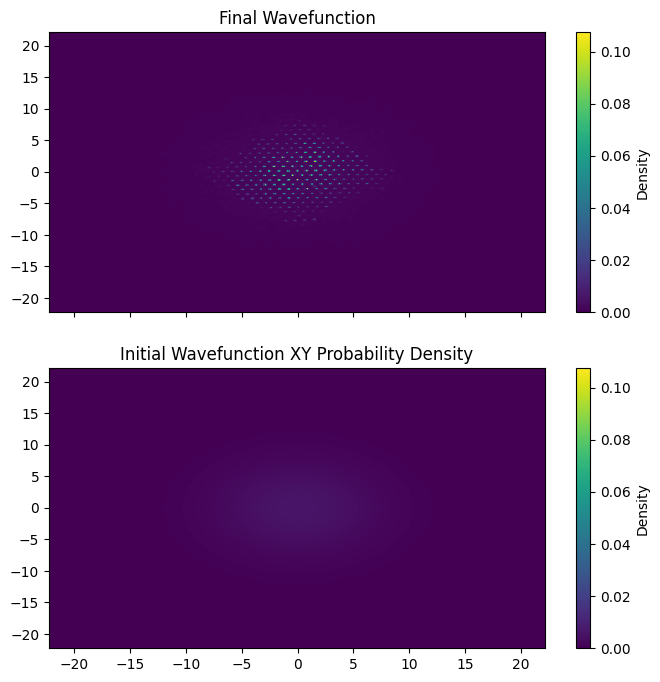

In [ ]:
sim = GPE(Np=1e5,
m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 1,
a02 = -3e-21,#2e-27,
sigma = 11e-6,
N=400,
ev_time = 0.01, #s
time_steps = 10000,
cutoff_coeff = 1/3,
cutoff="Soft Cutoff")

final_wf = sim.evolution()


x = sim.x.cpu().numpy()
pX, pY = np.meshgrid(x, x, indexing='ij')

init_psi = sim.init_wf.cpu().numpy()
initial_xy_density = np.sum(np.abs(init_psi)**2 * sim.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*sim.l**(3/2))**2 * sim.dx/sim.l, axis=2)

uxy_density = np.sum(np.abs(final_wf)**2 * sim.dx/sim.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * sim.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX/sim.l, pY/sim.l, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX/sim.l, pY/sim.l, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

Text(0.5, 1.0, 'Final wavefunction slice at x=0')

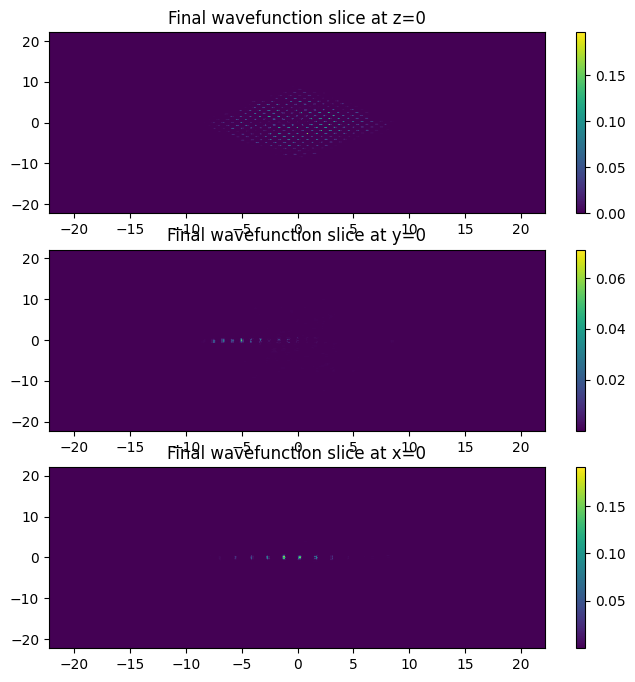

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

im1 = ax1.pcolormesh(pX/sim.l, pY/sim.l, np.abs(final_wf[:,:,len(final_wf)//2])**2)
fig.colorbar(im1, ax=ax1)
ax1.set_title("Final wavefunction slice at z=0")

im2 = ax2.pcolormesh(pX/sim.l, pY/sim.l, np.abs(final_wf[:,len(final_wf)//2,:])**2)
fig.colorbar(im2, ax=ax2)
ax2.set_title("Final wavefunction slice at y=0")

im3 = ax3.pcolormesh(pX/sim.l, pY/sim.l, np.abs(final_wf[len(final_wf)//2,:,:])**2)
fig.colorbar(im3, ax=ax3)
ax3.set_title("Final wavefunction slice at x=0")


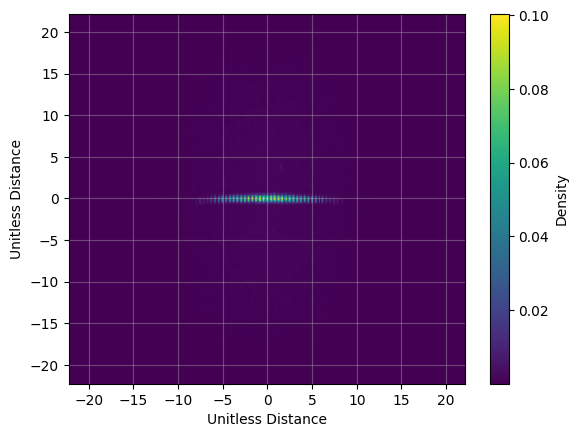

In [ ]:
uxz_density = np.sum(np.abs(final_wf)**2 * sim.dx/sim.l, axis=1)

fig5, ax5 = plt.subplots()
im5 = ax5.pcolormesh(pX/sim.l, pY/sim.l, uxz_density)
ax5.set_xlabel("Unitless Distance")
ax5.set_ylabel("Unitless Distance")
fig5.colorbar(im5, ax=ax5, label="Density")
ax5.grid(True, alpha=0.4)

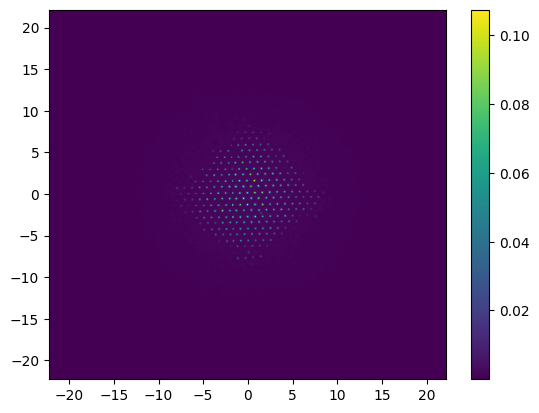

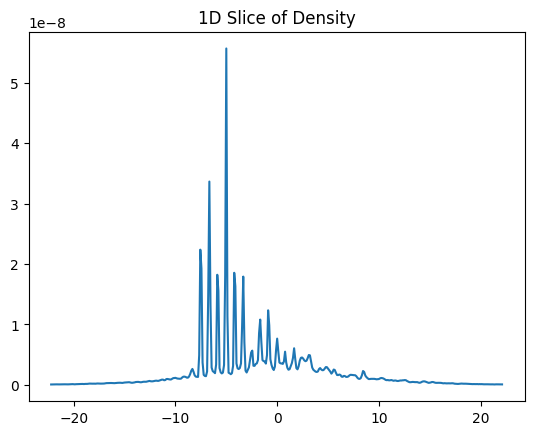

In [ ]:
plt.pcolormesh(pX/sim.l, pY/sim.l, uxy_density)
ax1.set_title("Final Wavefunction")
plt.colorbar()

plt.figure()
plt.plot(pX[:, sim.N//2] / sim.l, xy_density[:, sim.N//2])
plt.title("1D Slice of Density")
plt.show()

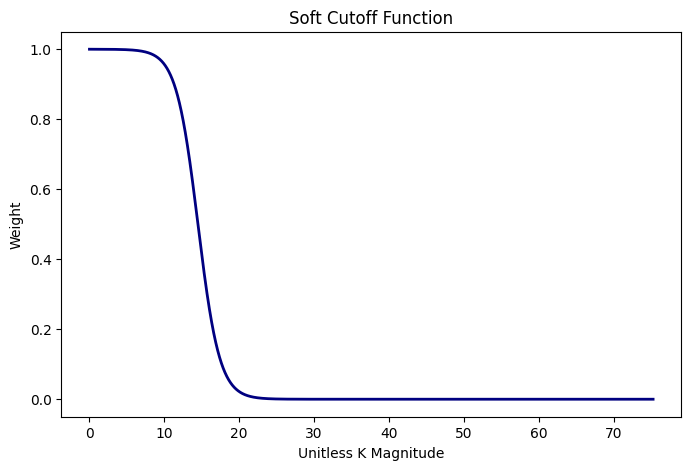

In [ ]:
#imaginary time evolution to find groun state
#plot energies to show converge

kx,ky,kz = sim.KX, sim.KY, sim.KZ

# Assuming you already have kx, ky, kz, and your evaluated 3D mask W_k
k_mag = torch.sqrt(kx**2 + ky**2 + kz**2)

W_k = sim.soft_cutoff()

# 1. Flatten the 3D arrays into 1D arrays
k_mag_flat = k_mag.flatten()
W_k_flat = W_k.flatten()

# 2. Get the sorting indices based on the momentum magnitude
sort_indices = torch.argsort(k_mag_flat)

# 3. Apply those indices to sort both arrays simultaneously
k_mag_sorted = k_mag_flat[sort_indices]
W_k_sorted = W_k_flat[sort_indices]

# 4. Plot to verify!
plt.figure(figsize=(8, 5))
plt.title("Soft Cutoff Function")
plt.xlabel("Unitless K Magnitude")
plt.ylabel("Weight")

# Since the data is sorted, a standard line plot will smoothly trace the sigmoid
plt.plot(k_mag_sorted.cpu().numpy(), W_k_sorted.cpu().numpy(), linewidth=2, color='navy', label='3D Array Data')

In [ ]:
def compute_energy(wf, ux, uy, uz, kx, ky, kz):

    wf_fft = torch.fft.fftn(wf)
    laplacian = 1/2 * (kx**2 + ky**2 + kz**2)
    qd = quadrupole_term(wf, kx, ky, kz)
    KE = torch.sum(laplacian * torch.abs(wf_fft)**2).real * GPE.dxu**3/GPE.N**3
    PE = torch.sum(trap_potential(ux, uy, uz) * torch.abs(wf)**2).real * GPE.dxu**3
    g0E = 0.5 * torch.sum(g0_term(wf) * torch.abs(wf)**2).real * GPE.dxu**3
    qE = 0.5 * torch.sum(qd * torch.abs(wf)**2).real * GPE.dxu**3

    return KE.item(), PE.item(), g0E.item(), qE.item(), KE.item()+PE.item()+g0E.item()+qE.item()


def imag_evolution():

    ev_time = GPE.ev_time
    time_steps = GPE.time_steps

    dxu = GPE.dxu

    dt = ev_time/time_steps
    dtau = dt/GPE.tau * -1j # unitless imaginary-time step

    N = GPE.N
    X, Y, Z = GPE.X, GPE.Y, GPE.Z
    uX, uY, uZ = GPE.uX, GPE.uY, GPE.uZ
    KX, KY, KZ = GPE.KX, GPE.KY, GPE.KZ
    dx = GPE.dx
    l = GPE.l

    assert dx < l

    wf = gaussian(X, Y, Z)
    print("Psi normalization:", torch.sum(torch.abs(wf)**2 * dx**3).item())

    #Nondimensionalization
    wf = (wf * l**(3/2)).to(GPE.complex_type) # could we just nondimensionalize the coordinate grid rather than the wavefunction? TODO

    potential_step = torch.exp(-1 *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = torch.exp(-1*(kinetic_energy(KX, KY, KZ)) * dtau)

    converge = False; prev_energy = 1e10; counter = 0; energies = []

    while not converge:

        wf = single_loop(wf, KX, KY, KZ, potential_step, KE_step, dtau)
        norm = torch.sum(torch.abs(wf)**2 * dxu**3)
        wf *= (1/norm)**(1/2)

        energy = compute_energy(wf, uX, uY, uZ, KX, KY, KZ)
        energies.append(energy)
        total = energy[-1]

        if abs(total - prev_energy)/abs(total) < 1e-6:
            break

        counter += 1

        if counter % 10 == 0:
            dprint(f"Energy: {total}, change: {abs(total-prev_energy)/abs(total)}, step: {counter}, norm: {norm}")

        prev_energy = total

    # Redimensionalize result

    redim_wf = wf* GPE.l**(-3/2)

    redim_wf = redim_wf.cpu().numpy()
    wf = wf.cpu().numpy()

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE.dx**3)

    return redim_wf, wf, energies

/tmp/ipykernel_52668/3025741020.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


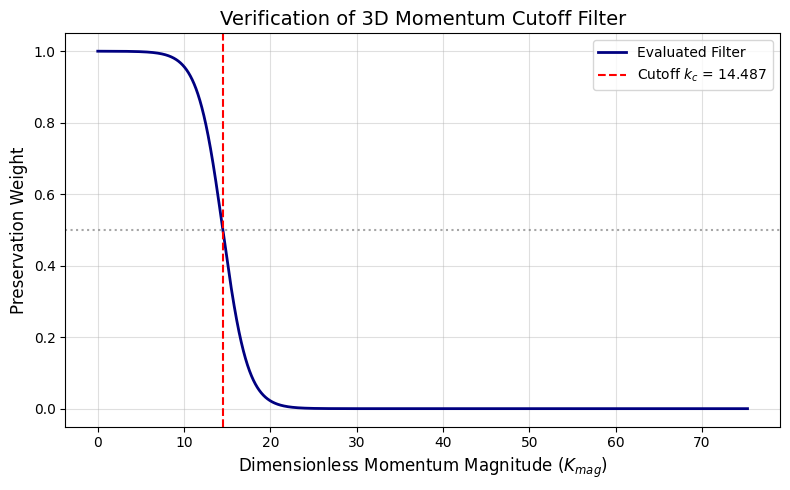

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Assuming this is inside your class/method and you have self.KX, self.KY, self.KZ
kc = sim.k_cutoff * sim.l
delta_k = 0.1 * sim.k_cutoff * sim.l  # Unitless smearing width

K_mag = torch.sqrt(sim.KX**2 + sim.KY**2 + sim.KZ**2)

# Unconditionally stable evaluation using PyTorch's built-in sigmoid
# Mathematically identical to 1 / (1 + exp((K_mag - kc)/delta_k))
sig = torch.sigmoid(-(K_mag - kc) / delta_k)

# ==========================================
# Plotting the 3D Tensors
# ==========================================

# 1. Detach, move to CPU, convert to NumPy, and flatten into 1D arrays
K_mag_np = K_mag.cpu().numpy().flatten()
sig_np = sig.cpu().numpy().flatten()

# 2. Sort the arrays by K_mag so Matplotlib can draw a continuous line
sort_idx = np.argsort(K_mag_np)
K_mag_sorted = K_mag_np[sort_idx]
sig_sorted = sig_np[sort_idx]

# 3. Plot the result
plt.figure(figsize=(8, 5))
plt.plot(K_mag_sorted, sig_sorted, linewidth=2, color='navy', label='Evaluated Filter')

# Reference lines
plt.axvline(kc, color='red', linestyle='--', label=f'Cutoff $k_c$ = {kc:.3f}')
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.7)

plt.title('Verification of 3D Momentum Cutoff Filter', fontsize=14)
plt.xlabel('Dimensionless Momentum Magnitude ($K_{mag}$)', fontsize=12)
plt.ylabel('Preservation Weight', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()